# CW5 - Generative Model for 32x32 Traffic Signs

Pipeline:
1. Przygotowanie danych (`ImageFolder`, normalizacja do `[-1, 1]`)
2. Definicja modeli (`Generator`, `Discriminator`)
3. Trening DCGAN
4. Wygenerowanie 1000 próbek i zapis do pliku `.pt`


In [1]:
# first of all put traffc_32.zip dataset into your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/trafic_32.zip /content/
!unzip -q /content/trafic_32.zip -d /content/

In [12]:
import os
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA available: True


In [13]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# find folders - if not on colab, maybe the local one
DATA_CANDIDATES = [
    Path('/content/drive/MyDrive/trafic_32'),
    Path('trafic_32'),
    Path('cw5') / 'trafic_32',
    Path.cwd() / 'trafic_32',
]

DATA_DIR = None
for p in DATA_CANDIDATES:
    if p.exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find 'trafic_32'."
    )

BATCH_SIZE = 128
NUM_WORKERS = 0 if os.name == 'nt' else 2
IMAGE_SIZE = 32
NC = 3          # num of channels (RGB)
NZ = 100        # latent_dim
NGF = 64        # size of generators feature map
NDF = 64        # size of discriminators feature map
NUM_EPOCHS = 150
LR_G = 2e-4
LR_D = 1e-4
BETA1 = 0.5
BETA2 = 0.999

OUTPUT_PT_NAME = 'sroda_baginski_gorski.pt'

print('Device:', device)
print('Data dir:', DATA_DIR)
print('NUM_WORKERS:', NUM_WORKERS)

Device: cuda
Data dir: trafic_32
NUM_WORKERS: 2


In [14]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}


class ImageFolderRecursive(Dataset):
    def __init__(self, root: str, image_size: int, extensions=IMG_EXTS):
        super().__init__()
        self.root = Path(root)
        self.image_size = image_size
        self.extensions = extensions

        samples = []
        class_names = set()

        for p in self.root.rglob('*'):
            if not p.is_file():
                continue
            if p.suffix.lower() not in self.extensions:
                continue

            rel = p.relative_to(self.root)
            if len(rel.parts) < 1:
                continue
            cls_name = rel.parts[0]

            class_names.add(cls_name)
            samples.append((p, cls_name))

        if not samples:
            raise FileNotFoundError(f'Nie znaleziono obrazów w: {self.root}')

        self.classes = sorted(class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = [(p, self.class_to_idx[c]) for (p, c) in samples]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path, label = self.samples[idx]

        img = Image.open(path).convert('RGB')
        img = img.resize((self.image_size, self.image_size), resample=Image.BICUBIC)

        arr = np.asarray(img, dtype=np.float32) / 255.0  # [H,W,C] w [0,1]
        x = torch.from_numpy(arr).permute(2, 0, 1)       # -> [C,H,W]
        x = (x - 0.5) / 0.5                             # -> [-1,1]

        return x, label


dataset = ImageFolderRecursive(root=str(DATA_DIR), image_size=IMAGE_SIZE)
print('Number of pictures:', len(dataset))
print('Number of classes:', len(dataset.classes))

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

n_total = len(dataset)
train_len = int(n_total * TRAIN_RATIO)
val_len = int(n_total * VAL_RATIO)
test_len = n_total - train_len - val_len

if val_len <= 0 or test_len <= 0:
    raise ValueError('Too little data to reasonably split dataset into train/val/tesst.')

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len], generator=generator)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    drop_last=False,
)

print('Sizes:', {'train': len(train_ds), 'val': len(val_ds), 'test': len(test_ds)})

sample_batch, _ = next(iter(train_loader))
print('Shape of batch (train):', sample_batch.shape)  # [B, 3, 32, 32]

Number of pictures: 39209
Number of classes: 43
Sizes: {'train': 31367, 'val': 3920, 'test': 3922}
Shape of batch (train): torch.Size([128, 3, 32, 32])


In [16]:
# =========================
# DCGAN
# =========================

class Generator(nn.Module):
    def __init__(self, nz: int = NZ, ngf: int = NGF, nc: int = NC):
        super().__init__()
        self.net = nn.Sequential(
            # input: [B, nz, 1, 1]
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),   # -> [B, ngf*4, 4, 4]
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),  # -> [B, ngf*2, 8, 8]
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),      # -> [B, ngf, 16, 16]
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),           # -> [B, nc, 32, 32]
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, nc: int = NC, ndf: int = NDF):
        super().__init__()
        self.net = nn.Sequential(
            # input: [B, nc, 32, 32]
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),  # -> [B, ndf, 16, 16]
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),  # -> [B, ndf*2, 8, 8]
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),  # -> [B, ndf*4, 4, 4]
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),  # -> [B, 1, 1, 1]
            # without sigmoid: using BCEWithLogitsLoss
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)
        return out.view(-1, 1)


def weights_init(m: nn.Module) -> None:
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


netG = Generator().to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), 

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, BETA2))

real_label = 1.0
fake_label = 0.0

G_losses = []
D_losses = []

VAL_EVAL_BATCHES = 10

for epoch in range(NUM_EPOCHS):
    netG.train()
    netD.train()

    epoch_g = 0.0
    epoch_d = 0.0
    n_steps = 0

    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        b_size = real_images.size(0)

        # (1) Update D network
        netD.zero_grad(set_to_none=True)

        label_real = torch.full((b_size, 1), real_label, device=device)
        output_real = netD(real_images)
        errD_real = criterion(output_real, label_real)

        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_images = netG(noise)
        label_fake = torch.full((b_size, 1), fake_label, device=device)
        output_fake = netD(fake_images.detach())
        errD_fake = criterion(output_fake, label_fake)

        errD = errD_real + errD_fake
        errD.backward()
        optimizerD.step()

        # (2) Update G network
        netG.zero_grad(set_to_none=True)

        # generator wants D to recognize fake as real
        label_gen = torch.full((b_size, 1), real_label, device=device)
        output_for_G = netD(fake_images)
        errG = criterion(output_for_G, label_gen)

        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        epoch_g += errG.item()
        epoch_d += errD.item()
        n_steps += 1

        if i % 100 == 0:
            print(
                f'Epoch [{epoch + 1}/{NUM_EPOCHS}] '
                f'Step [{i}/{len(train_loader)}] '
                f'Loss_D: {errD.item():.4f} '
                f'Loss_G: {errG.item():.4f}'
            )

    avg_train_g = epoch_g / max(1, n_steps)
    avg_train_d = epoch_d / max(1, n_steps)
    print(f'=== End of epoch {epoch + 1} | Avg Loss_D: {avg_train_d:.4f} | Avg Loss_G: {avg_train_g:.4f} ===\n')

print('Training complete :)')

Epoch [1/150] Step [0/245] Loss_D: 1.8116 Loss_G: 1.2065
Epoch [1/150] Step [100/245] Loss_D: 0.2088 Loss_G: 4.0546
Epoch [1/150] Step [200/245] Loss_D: 0.7787 Loss_G: 1.5514
=== End of epoch 1 | Avg Loss_D: 0.5385 | Avg Loss_G: 3.2671 ===

Epoch [2/150] Step [0/245] Loss_D: 0.6410 Loss_G: 1.9075
Epoch [2/150] Step [100/245] Loss_D: 0.7201 Loss_G: 1.8654
Epoch [2/150] Step [200/245] Loss_D: 0.8215 Loss_G: 1.8847
=== End of epoch 2 | Avg Loss_D: 0.7390 | Avg Loss_G: 2.2552 ===

Epoch [3/150] Step [0/245] Loss_D: 0.7738 Loss_G: 1.8494
Epoch [3/150] Step [100/245] Loss_D: 0.5033 Loss_G: 3.5513
Epoch [3/150] Step [200/245] Loss_D: 1.1902 Loss_G: 1.2761
=== End of epoch 3 | Avg Loss_D: 0.6447 | Avg Loss_G: 2.6833 ===

Epoch [4/150] Step [0/245] Loss_D: 0.6555 Loss_G: 2.6238
Epoch [4/150] Step [100/245] Loss_D: 0.5138 Loss_G: 2.1564
Epoch [4/150] Step [200/245] Loss_D: 0.6285 Loss_G: 2.6374
=== End of epoch 4 | Avg Loss_D: 0.6939 | Avg Loss_G: 2.4556 ===

Epoch [5/150] Step [0/245] Loss_D: 0

In [18]:
netG.eval()
with torch.no_grad():
    z = torch.randn(1000, NZ, 1, 1, device=device)
    generated_imgs = netG(z)

generated_imgs = (generated_imgs + 1.0) / 2.0
generated_imgs = generated_imgs.clamp(0.0, 1.0)

print('Shape of generated samples', generated_imgs.shape)  # [1000, 3, 32, 32]

torch.save(generated_imgs.cpu().detach(), OUTPUT_PT_NAME)
print(f'Tensor saved into: {OUTPUT_PT_NAME}')

Shape of generated samples torch.Size([1000, 3, 32, 32])
Tensor saved into: sroda_baginski_gorski.pt


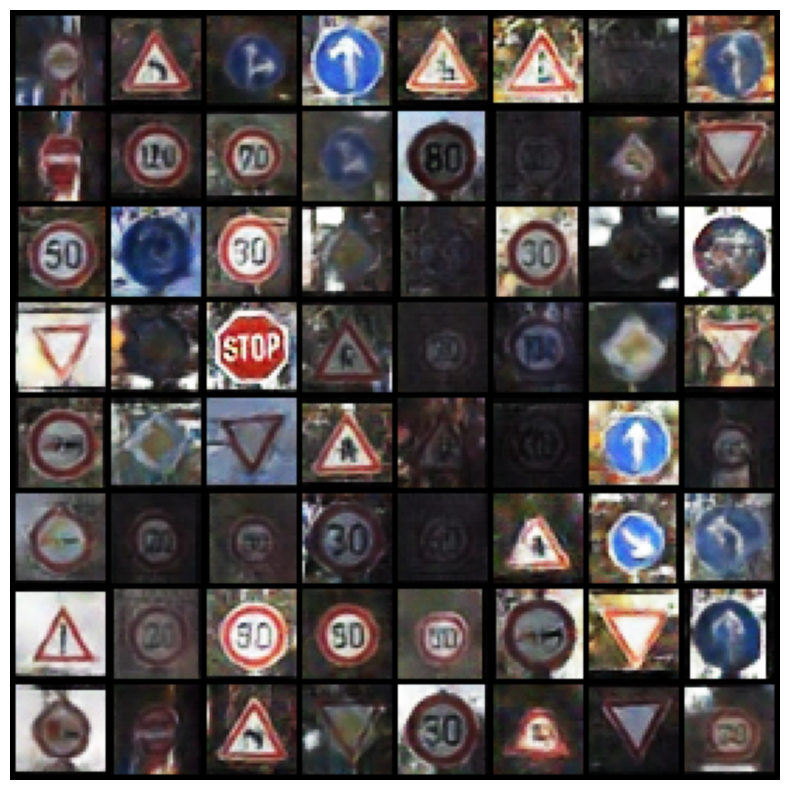

In [19]:
import matplotlib.pyplot as plt
import torchvision

samples = torch.load('sroda_baginski_gorski.pt')

grid = torchvision.utils.make_grid(samples[:64], nrow=8, padding=2)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [20]:
!pip install pytorch-fid -q

import os
import shutil
import torchvision
import torch

print("Preparing images to compute FID...")

real_dir = 'fid_real'
fake_dir = 'fid_fake'
os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

fakes = torch.load('sroda_baginski_gorski.pt')
for i, img in enumerate(fakes):
    torchvision.utils.save_image(img, f'{fake_dir}/fake_{i:04d}.png')

real_count = 0
for imgs, _ in test_loader:
    imgs = (imgs + 1.0) / 2.0
    imgs = imgs.clamp(0.0, 1.0)

    for img in imgs:
        if real_count < 1000:
            torchvision.utils.save_image(img, f'{real_dir}/real_{real_count:04d}.png')
            real_count += 1
        else:
            break
    if real_count >= 1000:
        break

print("Images saved. Computing FID...")

!python -m pytorch_fid fid_real fid_fake --device cuda:0

shutil.rmtree(real_dir)
shutil.rmtree(fake_dir)

Preparing images to compute FID...
Images saved. Computing FID...
100% 20/20 [00:05<00:00,  3.92it/s]
100% 20/20 [00:04<00:00,  4.15it/s]
FID:  69.03366493469997
